In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/zero-day-android-botnet-detection-using-nn/BotnetFull.csv


In [2]:
df = pd.read_csv("/kaggle/input/zero-day-android-botnet-detection-using-nn/BotnetFull.csv")

In [4]:
#Model-Based Feature Selection?

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

# Step 1: Load your dataset
df = pd.read_csv("/kaggle/input/zero-day-android-botnet-detection-using-nn/BotnetFull.csv")
df.columns = df.columns.str.replace('\n', '').str.strip()

# Step 2: Separate features and labels
X = df.iloc[:, :-1]  # Features
y = df.iloc[:, -1]   # Label

# Step 3: Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 4: Model-based feature selection
rf = RandomForestClassifier()
selector = SelectFromModel(rf)  # You can also set threshold='mean' explicitly
selector.fit(X_train, y_train)

# Step 5: Transform train and test data using selected features
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)

print(f"✅ Features before selection: {X.shape[1]}")
print(f"✅ Features after selection:  {X_train_selected.shape[1]}")


✅ Features before selection: 455
✅ Features after selection:  51


In [13]:
selected_features = X.columns[selector.get_support()]
print("🧠 Selected feature names:")
print(selected_features.tolist())

🧠 Selected feature names:
['internet', 'accesscoarselocation', 'accessfinelocation', 'gettasks', 'changewifistate', 'writeexternalstorage', 'readphonestate', 'systemalertwindow', 'c2dmessage', 'camera', 'callphone', 'bluetooth', 'manageaccounts', 'usecredentials', 'writecontacts', 'readcontacts', 'writesms', 'readsms', 'receivesms', 'sendsms', 'recordaudio', 'readhistorybookmarks', 'writehistorybookmarks', 'processoutgoingcalls', 'disablekeyguard', 'writeapnsettings', 'mountunmountfilesystems', 'modifyphonestate', 'ACCESSNETWORKSTATE', 'ACCESSWIFISTATE', 'MODIFYAUDIOSETTINGS', 'FOREGROUNDSERVICE', 'GETACCOUNTS', 'READEXTERNALSTORAGE', 'RECEIVEBOOTCOMPLETED', 'VIBRATE', 'WAKELOCK', 'BILLING', 'RECEIVE', 'BIND GETINSTALLREFERRERSERVICE', 'WRITESETTINGS', 'READGSERVICES', 'CHECKLICENSE', 'INSTALLSHORTCUT', 'SETWALLPAPER', 'RESTARTPACKAGES', 'UPDATESHORTCUT', 'UPDATECOUNT', 'UPDATEBADGE', 'READ', 'BROADCASTBADGE']


In [15]:
X_train_selected_df = pd.DataFrame(X_train_selected, columns=selected_features, index=X_train.index)
X_test_selected_df = pd.DataFrame(X_test_selected, columns=selected_features, index=X_test.index)


In [19]:
import shutil

shutil.rmtree("tuner_dir", ignore_errors=True)


In [ ]:
#now using above features to find the best model 

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Activation, Dropout, LeakyReLU
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import keras_tuner as kt

def build_model(hp):
    model = Sequential()

    # First hidden layer
    model.add(Dense(
        hp.Int('units_0', min_value=16, max_value=64, step=16),
        input_shape=(51,),
        use_bias=False,
        kernel_regularizer=l2(hp.Float('l2_reg', 1e-4, 1e-2, sampling='log'))
    ))
    model.add(BatchNormalization())

    # Choose activation: relu or leaky_relu
    activation_choice = hp.Choice('activation', ['relu'])
    if activation_choice == 'relu':
        model.add(Activation('relu'))
    else:
        model.add(LeakyReLU(alpha=0.01))

    model.add(Dropout(hp.Float('dropout_rate_0', 0.2, 0.3, step=0.1)))

    # Additional hidden layers
    for i in range(hp.Int('num_hidden_layers', 1, 2)):
        model.add(Dense(
            hp.Int(f'units_{i+1}', min_value=8, max_value=32, step=8),
            use_bias=False,
            kernel_regularizer=l2(hp.Float(f'l2_reg_{i+1}', 1e-4, 1e-2, sampling='log'))
        ))
        model.add(BatchNormalization())
        if activation_choice == 'relu':
            model.add(Activation('relu'))
        else:
            model.add(LeakyReLU(alpha=0.01))
        model.add(Dropout(hp.Float(f'dropout_rate_{i+1}', 0.3, 0.4, step=0.1)))

    # Output layer
    model.add(Dense(1, activation='sigmoid', kernel_regularizer=l2(0.001)))

    # Choose optimizer
    optimizer_choice = hp.Choice('optimizer', ['adam'])
    model.compile(optimizer=optimizer_choice, loss='binary_crossentropy', metrics=['accuracy'])

    return model

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Reduce learning rate when stuck
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-6)


# Create tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=20,
    directory='tuner_dir',
    project_name='botnet_tuning'
)

# Search including batch size tuning
tuner.search(
    X_train_selected, y_train,
    epochs=100,
    validation_split=0.2,
    batch_size=kt.HyperParameters().Choice('batch_size', [16, 32, 64, 128]),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Evaluate best model
best_model = tuner.get_best_models(num_models=1)[0]
test_loss, test_acc = best_model.evaluate(X_test_selected, y_test, verbose=0)
print(f"\n✅ Test Accuracy of best model: {test_acc * 100:.2f}%")


Trial 12 Complete [00h 00m 17s]
val_accuracy: 0.9783393740653992

Best val_accuracy So Far: 0.9855595827102661
Total elapsed time: 00h 03m 40s

Search: Running Trial #13

Value             |Best Value So Far |Hyperparameter
48                |32                |units_0
0.0015015         |0.00010818        |l2_reg
relu              |relu              |activation
0.2               |0.2               |dropout_rate_0
1                 |1                 |num_hidden_layers
8                 |32                |units_1
0.0051674         |0.007914          |l2_reg_1
0.4               |0.3               |dropout_rate_1
adam              |adam              |optimizer
8                 |24                |units_2
0.0022335         |0.0002585         |l2_reg_2
0.3               |0.3               |dropout_rate_2

Epoch 1/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.6572 - loss: 0.7813 - val_accuracy: 0.9458 - val_loss: 0.4852 - learning_rate: 0.0010
Epoch 2/100
139/139 ━━━━━━━━━━━━

In [ ]:
best_model = tuner.get_best_models(num_models=1)[0]
test_loss, test_acc = best_model.evaluate(X_test, y_test, verbose=0)
print(f"\n✅ Test Accuracy of best model: {test_acc * 100:.2f}%")

In [7]:
# Accuracy Comparison: No FS vs Chi² vs Model-Based (With Plot)


✅ Accuracy Comparison:
No Selection: 98.27%
Chi² (Top 100): 97.54%
Model-Based: 97.83%


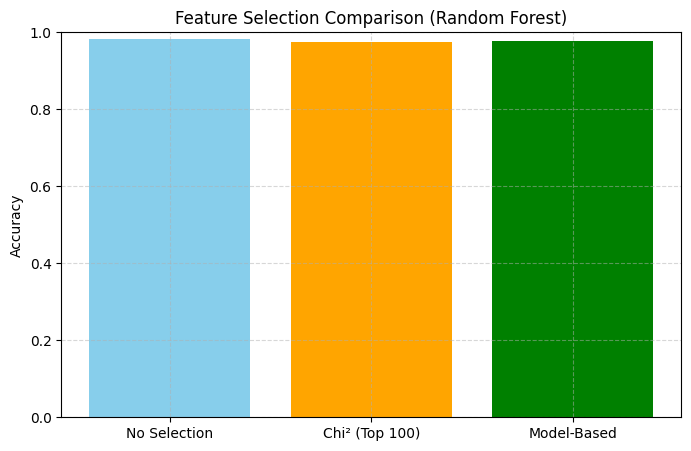

In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2, SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("/kaggle/input/zero-day-android-botnet-detection-using-nn/BotnetFull.csv")
df.columns = df.columns.str.replace('\n', '').str.strip()
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

results = {}

### 1️⃣ No Feature Selection
rf1 = RandomForestClassifier()
rf1.fit(X_train, y_train)
preds1 = rf1.predict(X_test)
results["No Selection"] = accuracy_score(y_test, preds1)

### 2️⃣ Chi-Squared Selection (Top 100)
chi_selector = SelectKBest(score_func=chi2, k=50)
X_train_chi = chi_selector.fit_transform(X_train, y_train)
X_test_chi = chi_selector.transform(X_test)

rf2 = RandomForestClassifier()
rf2.fit(X_train_chi, y_train)
preds2 = rf2.predict(X_test_chi)
results["Chi² (Top 50)"] = accuracy_score(y_test, preds2)

### 3️⃣ Model-Based Selection (RandomForest)
model = RandomForestClassifier()
model_selector = SelectFromModel(model)
model_selector.fit(X_train, y_train)
X_train_model = model_selector.transform(X_train)
X_test_model = model_selector.transform(X_test)

rf3 = RandomForestClassifier()
rf3.fit(X_train_model, y_train)
preds3 = rf3.predict(X_test_model)
results["Model-Based"] = accuracy_score(y_test, preds3)

# 🧪 Print Results
print("\n✅ Accuracy Comparison:")
for name, score in results.items():
    print(f"{name}: {score * 100:.2f}%")

# 📊 Plot
plt.figure(figsize=(8, 5))
plt.bar(results.keys(), results.values(), color=['skyblue', 'orange', 'green'])
plt.ylabel("Accuracy")
plt.title("Feature Selection Comparison (Random Forest)")
plt.ylim(0, 1)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1745830227.779573      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Epoch 1/50


I0000 00:00:1745830230.886350      93 service.cc:148] XLA service 0x7a4cf8023f80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1745830230.887370      93 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1745830231.149998      93 cuda_dnn.cc:529] Loaded cuDNN version 90300


37/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7827 - loss: 0.7846 

I0000 00:00:1745830232.224897      93 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.8453 - loss: 0.6288 - val_accuracy: 0.9793 - val_loss: 0.4226
Epoch 2/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9746 - loss: 0.1856 - val_accuracy: 0.9835 - val_loss: 0.2962
Epoch 3/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9686 - loss: 0.1658 - val_accuracy: 0.9793 - val_loss: 0.2105
Epoch 4/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9725 - loss: 0.1416 - val_accuracy: 0.9669 - val_loss: 0.1794
Epoch 5/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9855 - loss: 0.1170 - val_accuracy: 0.9793 - val_loss: 0.1451
Epoch 6/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9848 - loss: 0.1065 - val_accuracy: 0.9628 - val_loss: 0.1401
Epoch 7/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9869 - loss: 0.0995 - val_accuracy: 0.9752 - val_loss: 0.1350
Epoch 8/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9859 - loss: 0.0923 - val_accuracy: 0.9793 - val_loss: 0.1107
Ep

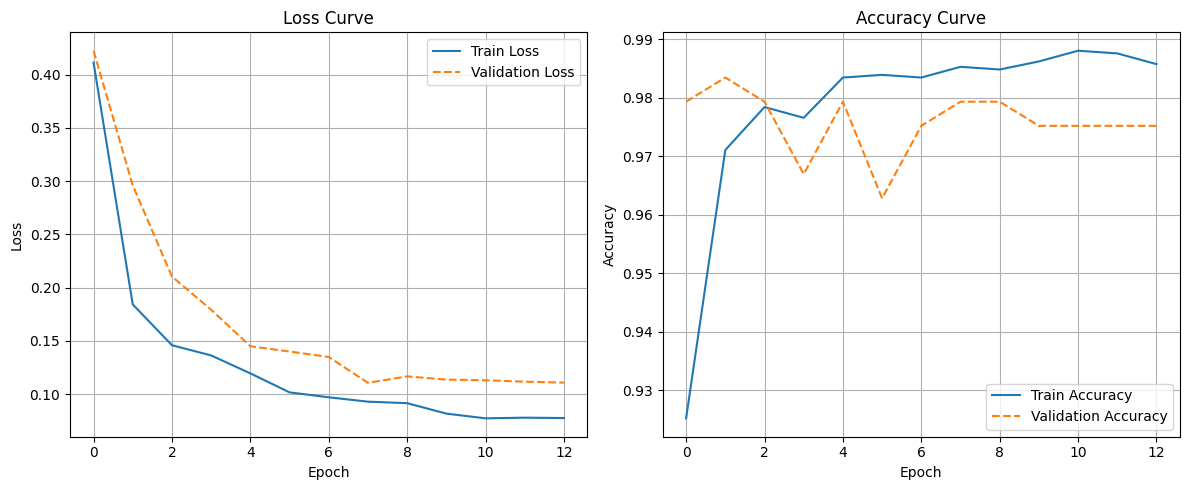

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout,BatchNormalization,Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from tensorflow.keras.regularizers import l2

# Step 1: Load and clean the dataset
df.columns = df.columns.str.replace('\n', '', regex=True).str.strip()

# Step 2: Split features and label (last column is label)
X = df.iloc[:, :-1].values  # First 455 columns = features
y = df.iloc[:, -1].values   # Last column = label (0 or 1)

# # Step 3: Normalize features
# scaler = StandardScaler()
# X = scaler.fit_transform(X)

# Step 4: Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=41, stratify=y
)

# Step 5: Define the MLP model
model4 = Sequential([
    Dense(454, input_shape=(455,),kernel_regularizer=l2(0.001), use_bias=False),  # Hidden layer
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.4),  # Dropout layer (50% dropout rate)
    Dense(1, activation='sigmoid',kernel_regularizer=l2(0.001))                      # Output layer
])

# Step 6: Compile the model4
optimizer = Adam(learning_rate=0.001)
model4.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Step 7: Add Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Step 8: Train the model4
history = model4.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Step 9: Evaluate on test set
test_loss, test_acc = model4.evaluate(X_test, y_test, verbose=0)
print(f"\n✅ Test Accuracy: {test_acc * 100:.2f}%")

# Step 10: Plot loss and accuracy curves
plt.figure(figsize=(12, 5))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss', linestyle='--')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linestyle='--')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Step 11: Save the model4
# model2.save("botnet_original_arch_dropout.h5")
# print("✅ Model saved as 'botnet_mlp_model_keras.h5'")



In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Activation, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt

def build_model(hp):
    model = Sequential()
    model.add(Dense(hp.Int('units', min_value=32, max_value=448), input_shape=(455,), use_bias=False))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dropout(0.4))
    model.add(Dense(1, activation='sigmoid', kernel_regularizer=l2(0.001)))

    optimizer = hp.Choice('optimizer', values=['adam','rmsprop'])

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

# Early stopping callback
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=False
)

# Create tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=100
)

# Start tuning
tuner.search(
    X_train, y_train,
    epochs=50,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)


Trial 100 Complete [00h 00m 08s]
val_accuracy: 0.9816955924034119

Best val_accuracy So Far: 0.9836223721504211
Total elapsed time: 00h 12m 54s


In [10]:
tuner.get_best_hyperparameters()[0].values


{'units': 56, 'optimizer': 'rmsprop'}

In [5]:
print("doing all params")

doing all params


In [7]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Activation, Dropout, LeakyReLU
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import keras_tuner as kt
# Step 1: Load and clean the dataset
df.columns = df.columns.str.replace('\n', '', regex=True).str.strip()

# Step 2: Split features and label (last column is label)
df = pd.read_csv("/kaggle/input/zero-day-android-botnet-detection-using-nn/BotnetFull.csv")
X = df.iloc[:, :-1].values  # First 455 columns = features
y = df.iloc[:, -1].values   # Last column = label (0 or 1)
def build_model(hp):
    model = Sequential()

    # First hidden layer
    model.add(Dense(
        hp.Int('units_0', min_value=32, max_value=128, step=32),
        input_shape=(455,),
        use_bias=False,
        kernel_regularizer=l2(hp.Float('l2_reg', 1e-4, 1e-2, sampling='log'))
    ))
    model.add(BatchNormalization())

    # Choose activation: relu or leaky_relu
    activation_choice = hp.Choice('activation', ['leaky_relu'])
    if activation_choice == 'relu':
        model.add(Activation('relu'))
    else:
        model.add(LeakyReLU(alpha=0.01))

    model.add(Dropout(hp.Float('dropout_rate_0', 0.2, 0.5, step=0.1)))

    # Additional hidden layers
    for i in range(hp.Int('num_hidden_layers', 1, 5)):
        model.add(Dense(
            hp.Int(f'units_{i+1}', min_value=32, max_value=128, step=32),
            use_bias=False,
            kernel_regularizer=l2(hp.Float(f'l2_reg_{i+1}', 1e-4, 1e-2, sampling='log'))
        ))
        model.add(BatchNormalization())
        if activation_choice == 'relu':
            model.add(Activation('relu'))
        else:
            model.add(LeakyReLU(alpha=0.01))
        model.add(Dropout(hp.Float(f'dropout_rate_{i+1}', 0.2, 0.5, step=0.1)))

    # Output layer
    model.add(Dense(1, activation='sigmoid', kernel_regularizer=l2(0.001)))

    # Choose optimizer
    optimizer_choice = hp.Choice('optimizer', ['adam'])
    model.compile(optimizer=optimizer_choice, loss='binary_crossentropy', metrics=['accuracy'])

    return model

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Reduce learning rate when stuck
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-6)

# Train-test split properly
from sklearn.model_selection import train_test_split

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=22, stratify=y
)

# Create tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=100,
    directory='tuner_dir',
    project_name='botnet_tuning'
)

# Search including batch size tuning
tuner.search(
    X_train_full, y_train_full,
    epochs=100,
    validation_split=0.2,
    batch_size=kt.HyperParameters().Choice('batch_size', [16, 32, 64, 128]),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Evaluate best model
best_model = tuner.get_best_models(num_models=1)[0]
test_loss, test_acc = best_model.evaluate(X_test, y_test, verbose=0)
print(f"\n✅ Test Accuracy of best model: {test_acc * 100:.2f}%")


Trial 100 Complete [00h 00m 38s]
val_accuracy: 0.9855595827102661

Best val_accuracy So Far: 0.9909747242927551
Total elapsed time: 00h 48m 05s


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:713: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 24 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



✅ Test Accuracy of best model: 98.12%


In [7]:
tuner.get_best_hyperparameters()[0].values

NameError: name 'tuner' is not defined

In [9]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_score, recall_score, accuracy_score
import numpy as np

# Evaluate best model
best_model = tuner.get_best_models(num_models=1)[0]

# K-Fold Validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_accuracies = []
cv_precisions = []
cv_recalls = []

for train_index, val_index in kf.split(X_test, y_test):  # Use TEST set for final CV
    X_train_kf, X_val_kf = X_test[train_index], X_test[val_index]
    y_train_kf, y_val_kf = y_test[train_index], y_test[val_index]
    
    # Predict probabilities first
    y_pred_probs = best_model.predict(X_val_kf)
    
    # Threshold to get final predicted class (binary)
    y_pred = (y_pred_probs >= 0.5).astype(int)

    # Compute metrics
    acc = accuracy_score(y_val_kf, y_pred)
    prec = precision_score(y_val_kf, y_pred)
    rec = recall_score(y_val_kf, y_pred)

    cv_accuracies.append(acc)
    cv_precisions.append(prec)
    cv_recalls.append(rec)

# Print results
print("\n✅ Cross-Validation Results:")
for fold_idx in range(5):
    print(f"Fold {fold_idx+1}: Accuracy = {cv_accuracies[fold_idx]*100:.2f}%, Precision = {cv_precisions[fold_idx]*100:.2f}%, Recall = {cv_recalls[fold_idx]*100:.2f}%")

print("\n✅ Overall Cross-Validation Metrics:")
print(f"Mean Accuracy: {np.mean(cv_accuracies)*100:.2f}% (+/- {np.std(cv_accuracies)*100:.2f})")
print(f"Mean Precision: {np.mean(cv_precisions)*100:.2f}% (+/- {np.std(cv_precisions)*100:.2f})")
print(f"Mean Recall: {np.mean(cv_recalls)*100:.2f}% (+/- {np.std(cv_recalls)*100:.2f})")


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 

✅ Cross-Validation Results:
Fold 1: Accuracy = 98.56%, Precision = 98.55%, Recall = 98.55%
Fold 2: Accuracy = 98.56%, Precision = 100.00%, Recall = 97.14%
Fold 3: Accuracy = 97.83%, Precision = 100.00%, Recall = 95.65%
Fold 4: Accuracy = 98.55%, Precision = 97.18%, Recall = 100.00%
Fold 5: Accuracy = 97.10%, Precision = 95.77%, Recall = 98.55%

✅ Overall Cross-Validation Metrics:
Mean Accuracy: 98.12% (+/- 0.58)
Mean Precision: 98.30% (+/- 1.64)
Mean Recall: 97.98% (+/- 1.47)


In [3]:
# getting accuracy and loss curves for val vs train , nd doing k fold validation

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


78/78 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.6830 - loss: 1.2123 - val_accuracy: 0.8700 - val_loss: 0.8736
Epoch 2/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9220 - loss: 0.5766 - val_accuracy: 0.9639 - val_loss: 0.5797
Epoch 3/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9421 - loss: 0.4292 - val_accuracy: 0.9783 - val_loss: 0.3964
Epoch 4/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9604 - loss: 0.3512 - val_accuracy: 0.9747 - val_loss: 0.3002
Epoch 5/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9747 - loss: 0.2723 - val_accuracy: 0.9747 - val_loss: 0.2423
Epoch 6/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9653 - loss: 0.2738 - val_accuracy: 0.9783 - val_loss: 0.2119
Epoch 7/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9691 - loss: 0.2425 - val_accuracy: 0.9783 - val_loss: 0.1904
Epoch 8/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9696 - loss: 0.2053 - val_accuracy: 0.9819 - val_loss: 0.

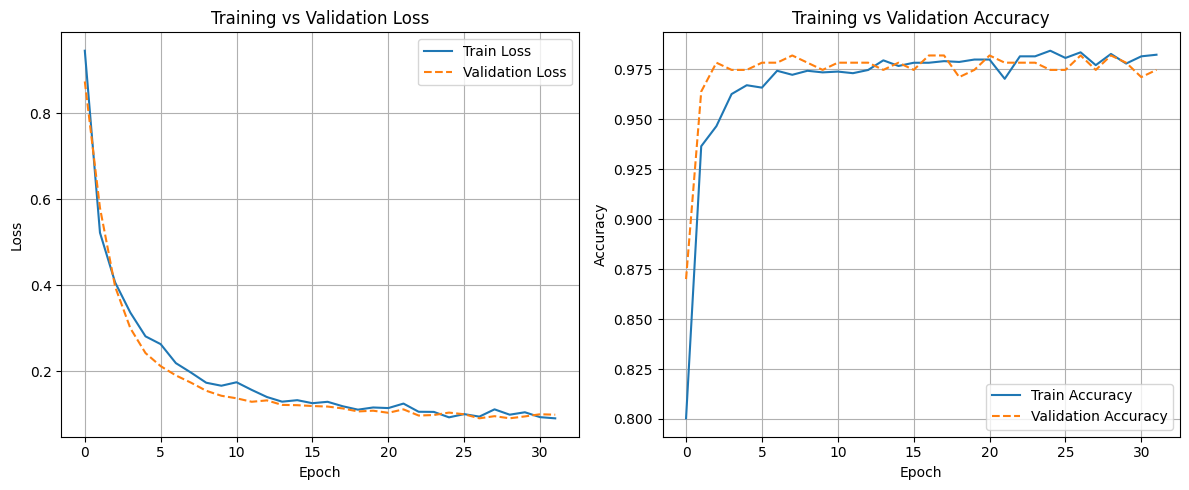


✅ Test Accuracy: 97.69%
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


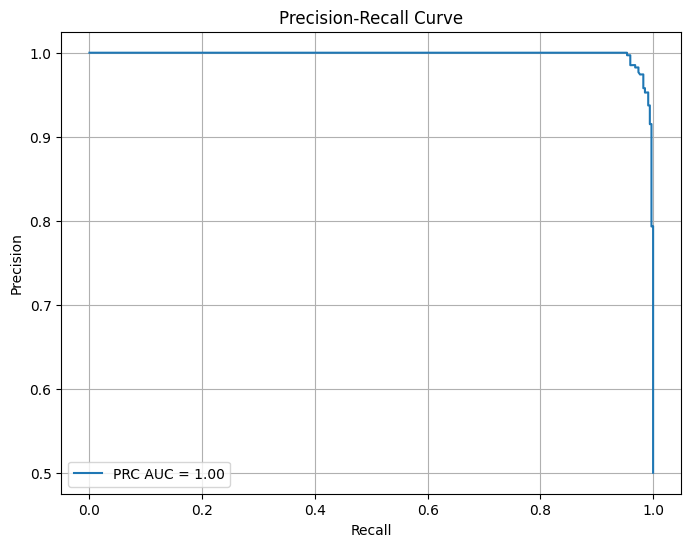


✅ K-Fold Cross Validation Results:


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Fold 1: Accuracy = 93.21%, Recall = 90.46%


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
Fold 2: Accuracy = 93.06%, Recall = 86.99%


...

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Fold 3: Accuracy = 86.99%, Recall = 73.99%


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Fold 4: Accuracy = 85.38%, Recall = 70.72%


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Fold 5: Accuracy = 80.03%, Recall = 60.12%

✅ Overall Cross-Validation Metrics:
Mean Accuracy: 87.74% (+/- 4.98)
Mean Recall: 76.46% (+/- 11.07)


In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import precision_score, recall_score, accuracy_score, precision_recall_curve, auc
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
import matplotlib.pyplot as plt

# Step 1: Load and clean the dataset
df = pd.read_csv("/kaggle/input/zero-day-android-botnet-detection-using-nn/BotnetFull.csv")
df.columns = df.columns.str.replace('\n', '', regex=True).str.strip()

# Step 2: Split features and label
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# Step 3: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=41, stratify=y
)

# Step 4: Define the best MLP model
def build_best_model():
    model = Sequential([
        Dense(32, input_shape=(455,), kernel_regularizer=l2(0.00757462956673712), use_bias=False),
        BatchNormalization(),
        Activation('relu'),
        Dropout(0.3),

        Dense(32, kernel_regularizer=l2(0.0016917010484983677), use_bias=False),
        BatchNormalization(),
        Activation('relu'),
        Dropout(0.2),

        Dense(96, kernel_regularizer=l2(0.005078365943126465), use_bias=False),
        BatchNormalization(),
        Activation('relu'),
        Dropout(0.2),

        Dense(1, activation='sigmoid', kernel_regularizer=l2(0.001))
    ])
    
    optimizer = Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Step 5: Train on the main train-test split
model4 = build_best_model()

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model4.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Step 6: Plot Training vs Validation Loss and Accuracy
plt.figure(figsize=(12, 5))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss', linestyle='--')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linestyle='--')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Step 7: Evaluate on test set
test_loss, test_acc = model4.evaluate(X_test, y_test, verbose=0)
print(f"\n✅ Test Accuracy: {test_acc * 100:.2f}%")

# Step 8: Plot Precision-Recall Curve
y_probs = model4.predict(X_test).ravel()
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
prc_auc = auc(recall, precision)

plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f'PRC AUC = {prc_auc:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

# Step 9: Perform K-Fold Cross Validation (5 folds)
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=41)

fold = 1
cv_accuracies = []
cv_recalls = []

print("\n✅ K-Fold Cross Validation Results:")

for train_idx, val_idx in kf.split(X, y):
    X_train_kf, X_val_kf = X[train_idx], X[val_idx]
    y_train_kf, y_val_kf = y[train_idx], y[val_idx]
    
    model_kf = build_best_model()
    
    history_kf = model_kf.fit(
        X_train_kf, y_train_kf,
        epochs=100,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=0
    )
    
    y_val_probs = model_kf.predict(X_val_kf).ravel()
    y_val_preds = (y_val_probs >= 0.5).astype(int)

    acc = accuracy_score(y_val_kf, y_val_preds)
    rec = recall_score(y_val_kf, y_val_preds)

    print(f"Fold {fold}: Accuracy = {acc*100:.2f}%, Recall = {rec*100:.2f}%")
    cv_accuracies.append(acc)
    cv_recalls.append(rec)
    
    fold += 1

print("\n✅ Overall Cross-Validation Metrics:")
print(f"Mean Accuracy: {np.mean(cv_accuracies)*100:.2f}% (+/- {np.std(cv_accuracies)*100:.2f})")
print(f"Mean Recall: {np.mean(cv_recalls)*100:.2f}% (+/- {np.std(cv_recalls)*100:.2f})")
